# Animation frame examples

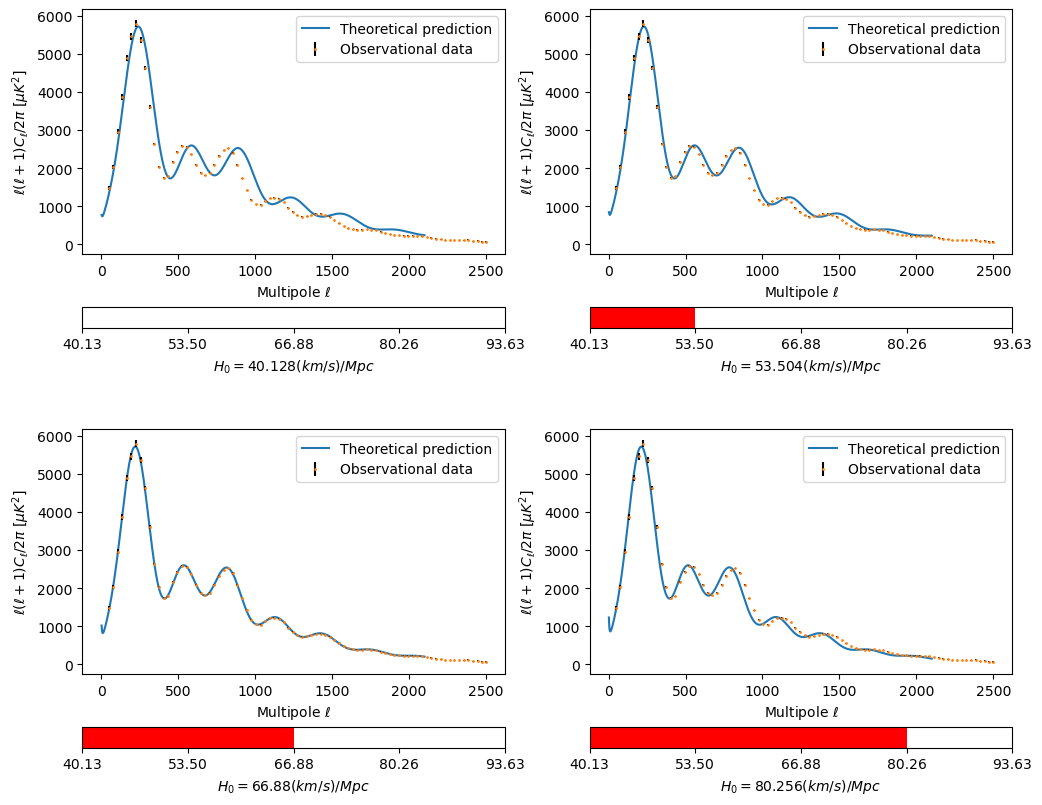

In [10]:
from config import DATA_PATH, RESULTS_PATH
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors

# Parameter values
params = [40.128, 53.504, 66.88,  80.256, 93.632]

# Load the observational points
binned = np.loadtxt(DATA_PATH / 'binned.txt')
x_b = binned[:,0]
y_b = binned[:,1]
yerr1 = binned[:,2]
yerr2 = binned[:,3]
err = np.array([yerr1,yerr2])

# Load data for ALL parameters at once, then access it sequentially
all_data = {
    p: np.loadtxt(DATA_PATH / f'HUBBLE/h{p}.txt')
    for p in params
}

# Create 2x2 subplot canvas and reshape it for easy access
fig, ax = plt.subplots(2,2, figsize=(12,10))
ax=ax.reshape(-1)
                    
for i, p in enumerate(params):
    
    # Update the colorbar with red and white sections
    colors=['red']*i+['white']*(len(params)-1-i)
    
    # Recalculate colormap and draw colorbar
    cmap = mpl.colors.ListedColormap(colors)
    norm = mpl.colors.BoundaryNorm(params, cmap.N)
    cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  orientation='horizontal',label=f"$H_0={p}(km/s)/Mpc$", ax=ax[i])
    cbar.set_ticks(params)
    
    # Access the data for the current value of the parameter
    data = all_data[p]
    x = data[:,0]
    y = data[:,1]
    
    # Draw the curve for the current parameter in its corresponding subplot
    ax[i].plot(x,y, label='Theoretical prediction')
    ax[i].errorbar(x_b, y_b, yerr=err, fmt='o', markersize=1, ecolor='k', label='Observational data')
    
    # Axes labels and legend
    ax[i].set(xlabel='Multipole $\ell$', ylabel='$ \ell(\ell+1)C_{\ell}/2 \pi \ [\mu K^2]$')
    ax[i].legend()
    
    # Since we're only drawing four frames and we have 5 parameter values, without this an error happens
    #because we're indexing outside of range in ax[i].
    if i==3:
        break
    
# Save image to memory
fig.savefig(RESULTS_PATH / f'HUBBLE/hframes.pdf', bbox_inches = 'tight')

---
# All curves

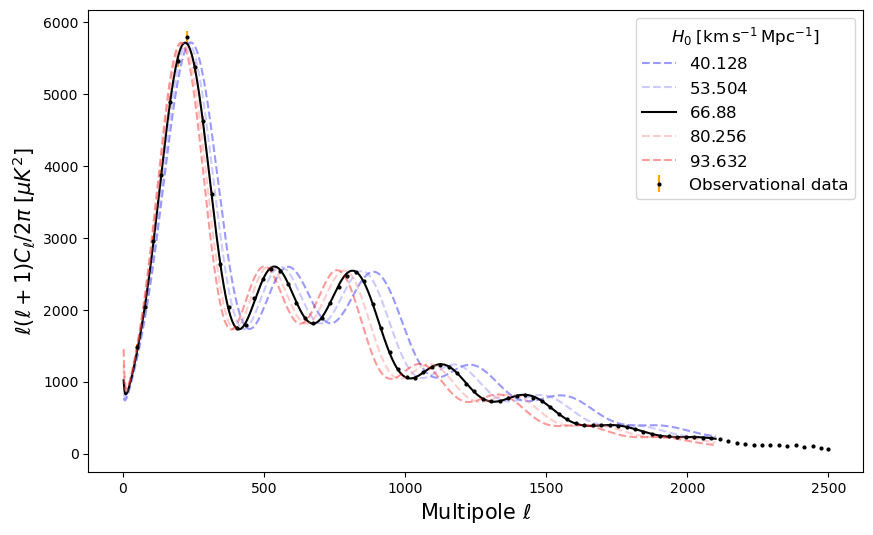

In [8]:
from config import DATA_PATH, RESULTS_PATH
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors

# Parameter values
params = [40.128, 53.504, 66.88,  80.256, 93.632]

# Color normalization and colormap
cmap = plt.get_cmap('bwr')
norm = colors.Normalize(vmin=params[0], vmax=params[-1])

# Load the observational points
binned = np.loadtxt(DATA_PATH / 'binned.txt')
x_b = binned[:,0]
y_b = binned[:,1]
yerr1 = binned[:,2]
yerr2 = binned[:,3]
err = np.array([yerr1,yerr2])

# Load data for ALL parameters at once, then access it sequentially
all_data = {
    p: np.loadtxt(DATA_PATH / f'HUBBLE/h{p}.txt')
    for p in params
}

# Create the canvas and plot observational points
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(x_b, y_b, yerr=err, fmt='o', markersize=2, ecolor='orange', c='k', label='Observational data')

for i, p in enumerate(params): # Loop through parameter values and plot the curves
    
    color = cmap(norm(p))
    
    data = all_data[p]
    x = data[:,0]
    y = data[:,1]
    
    # To make the optimal value stand out, we draw it differently inside the else statement
    if i!=2:
        ax.plot(x, y, alpha=0.4, c=color, ls='--', label=f'${p}$')
        
    else:
        ax.plot(x, y, c='k', label=f'${p}$')

# Axes labels and legend
ax.set_xlabel("Multipole $\ell$", fontsize=15)
ax.set_ylabel('$\ell(\ell+1)C_{\ell}/2 \pi \ [\mu K^2]$', fontsize=15)
plt.legend(fontsize=12, title=r'$H_0 \;[\mathrm{km\,s^{-1}\,Mpc^{-1}}]$', title_fontsize=12)
    
# Save image to memory       
fig.savefig(RESULTS_PATH / f'HUBBLE/h_todas.pdf', format='pdf', bbox_inches = 'tight')

---
# Animation

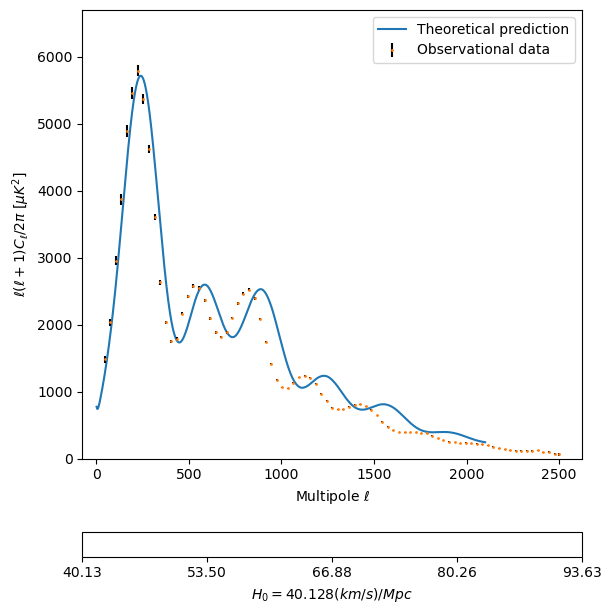

In [18]:
from config import DATA_PATH, RESULTS_PATH
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors
from matplotlib.animation import FuncAnimation

# Parameter values
params = [40.128, 53.504, 66.88,  80.256, 93.632]

# Load the observational points
binned = np.loadtxt(DATA_PATH / 'binned.txt')
x_b = binned[:,0]
y_b = binned[:,1]
yerr1 = binned[:,2]
yerr2 = binned[:,3]
err = np.array([yerr1,yerr2]) 

# Load data for ALL parameters at once, then access it sequentially
all_data = {
    p: np.loadtxt(DATA_PATH / f'HUBBLE/h{p}.txt')
    for p in params
}

# Create the canvas and an empty curve, which will be updated at each step of the animation
fig, ax = plt.subplots(figsize=(6,6), constrained_layout=True)
line = ax.plot([],[],label='Theoretical prediction')

# Some canvas configuration and observational points
ax.set(xlabel="Multipole $\ell$", ylabel="$\ell(\ell+1)C_{\ell}/2 \pi \ [\mu K^2]$", ylim=[0,6700])
ax.errorbar(x_b, y_b, yerr=err, fmt='o', markersize=1, ecolor='k', label='Observational data')
ax.legend()

# Create a blank colorbar, to be updated later
colors = ['white']*len(params)
cmap = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(params, cmap.N)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(sm, orientation='horizontal', label=f"$H_0={params[0]} (km/s)/Mpc$", ax=ax)

def update(i): # Update function for the animation
    
    # Update parameter value
    p = params[i]
    
    # Update the colorbar
    colors = ['red']*i+['white']*(len(params)-1-i)
    cmap = mpl.colors.ListedColormap(colors)
    sm.set_cmap(cmap) 
    cbar.set_label(f'$H_0={p} (km/s)/Mpc$')
    
    # Set the data to be plotted
    data = all_data[p]
    x = data[:,0]
    y = data[:,1]
    
    # Update the curve with the new data
    line[0].set_data(x,y)
    
    
    
    return line,

# Generate the animation and save it to memory
animation = FuncAnimation(fig, update, len(params))
animation.save(RESULTS_PATH / 'HUBBLE/animation.gif', fps = 1.5, writer='pillow') 

---
# Only binned data and optimal parameters curve

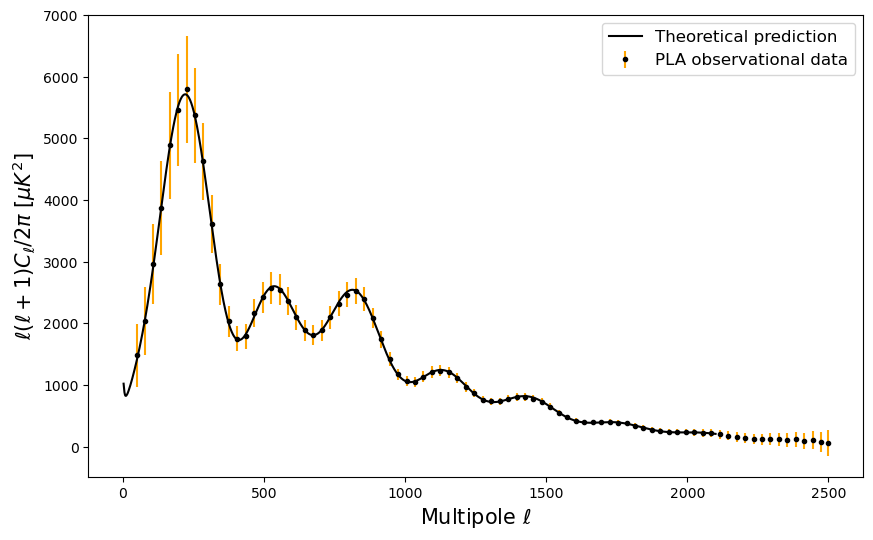

In [7]:
from config import DATA_PATH, RESULTS_PATH
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors

# Theoretical curve with PLANCK optimal values
data = np.loadtxt(DATA_PATH / 'HUBBLE/h66.88.txt')
x_t = data[:,0]
y_t = data[:,1]

# Observational data
binned = np.loadtxt(DATA_PATH / 'binned.txt')
x_b = binned[:, 0]
y_b = binned[:, 1]
yerr1 = binned[:, 2]
yerr2 = binned[:, 3]

# Multiply errors by 5
err = 10 * np.array([yerr1, yerr2])

# Create the canvas
fig, ax = plt.subplots(figsize=(10, 6))

# Plot binned points
ax.errorbar(
    x_b,
    y_b,
    yerr=err,
    fmt='o',
    markersize=3,
    ecolor='orange',
    c='k',
    label='PLA observational data'
)

# Plot theoretical curve
ax.plot(x_t,y_t, c='k', label='Theoretical prediction')

# Figure configuration: axis labels, legend
ax.set_xlabel('Multipole $\ell$', fontsize=15)
ax.set_ylabel('$\ell(\ell+1)C_{\ell}/2\pi\ [\mu K^2]$', fontsize=15)

ax.legend(fontsize=12)

# Save image to memory
fig.savefig(
    RESULTS_PATH / 'HUBBLE/binned_only.pdf',
    format='pdf',
    bbox_inches='tight'
)
